# Monkey microsaccade detection

End-to-end pipeline on the monkey sample shipped in this repo:
load → preprocess → EK detection → 15 ms binned rate → RBF-SVM decoding,
following Nouri et al. 2025 (iScience 28:111584).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from msfeature.io import load_session
from msfeature.config import MONKEY_CONFIG
from msfeature.preprocess import preprocess_trial
from msfeature.detect import detect_microsaccades
from msfeature.features import (
    NOURI_RATE_BINS, RateBinSpec,
    binned_rate, shift_to_onset, stack_trial_features,
)
from msfeature.decode import cross_validate

# --- Plot styling --------------------------------------------------------
sns.set_theme(
    context='notebook', style='ticks', palette='deep', font_scale=1.05,
    rc={
        'axes.spines.top': False, 'axes.spines.right': False,
        'axes.titleweight': 'semibold', 'axes.titlesize': 'medium',
        'axes.labelsize': 'small', 'xtick.labelsize': 'small',
        'ytick.labelsize': 'small', 'legend.frameon': False,
        'legend.fontsize': 'small', 'figure.dpi': 110, 'savefig.dpi': 150,
    },
)
PALETTE = sns.color_palette('deep')
FACE_COLOUR    = PALETTE[3]
NONFACE_COLOUR = PALETTE[0]
ACCENT         = PALETTE[2]
GREY           = (0.5, 0.5, 0.5)

## 1. Load + report configuration

In [2]:
ds = load_session('../data/monkey_sample/sample_1_EyeData.mat')
cfg = MONKEY_CONFIG
print(f'{ds.n_trials} trials, {ds.n_samples} samples per trial')
print(f'face={ds.is_face.sum()}  non-face={(~ds.is_face).sum()}'
      f'  (majority-class baseline {max(ds.is_face.mean(), 1-ds.is_face.mean())*100:.1f}%)')
print(f'unique stimulus codes: {len(np.unique(ds.stimulus_code))}')
print()
print(f'fs                   = {cfg.sampling_rate_hz:.0f} Hz')
print(f'trial duration       = {ds.n_samples/cfg.sampling_rate_hz*1000:.0f} ms')
print(f'stim onset           = sample {cfg.stim_onset_sample}'
      f' ({cfg.stim_onset_sample/cfg.sampling_rate_hz*1000:.0f} ms baseline)')
print(f'lambda               = {cfg.velocity_threshold_lambda}')
print(f'sigma_method         = {cfg.sigma_method}')
print(f'min/max duration     = {cfg.min_duration_ms} / {cfg.max_duration_ms} ms')
print(f'amplitude cap        = {cfg.max_amplitude_deg}°')
print(f'refractory merge     = {cfg.refractory_merge_ms} ms')
print(f'amp outlier rejection= {cfg.amplitude_outlier_sd} SD')
print(f'lowpass              = {cfg.lowpass_cutoff_hz}')

774 trials, 900 samples per trial
face=225  non-face=549  (majority-class baseline 70.9%)
unique stimulus codes: 155

fs                   = 1000 Hz
trial duration       = 900 ms
stim onset           = sample 250 (250 ms baseline)
lambda               = 6.0
sigma_method         = engbert2015
min/max duration     = 6.0 / 100.0 ms
amplitude cap        = 1.0°
refractory merge     = 30.0 ms
amp outlier rejection= 2.5 SD
lowpass              = None


## 2. Preprocess + detect microsaccades on every trial

In [3]:
events_per_trial = []
blink_trials = 0
for i in range(ds.n_trials):
    x, y, blink_mask = preprocess_trial(
        ds.eye_x[i], ds.eye_y[i],
        sampling_rate_hz=cfg.sampling_rate_hz,
        lowpass_cutoff_hz=cfg.lowpass_cutoff_hz,
    )
    if blink_mask.any():
        blink_trials += 1
    raw_evs = detect_microsaccades(x, y, cfg)
    events_per_trial.append(
        shift_to_onset(raw_evs, cfg.stim_onset_sample, cfg.dt)
    )

n_per_trial = np.array([len(e) for e in events_per_trial])
print(f'>=1 MS in {(n_per_trial>0).sum()} / {ds.n_trials} trials'
      f' ({(n_per_trial>0).mean()*100:.1f}%)')
print(f'events/trial mean={n_per_trial.mean():.2f}'
      f'  median={np.median(n_per_trial):.0f}  max={n_per_trial.max()}')
print(f'trials flagged as blink-containing: {blink_trials}')

>=1 MS in 667 / 774 trials (86.2%)
events/trial mean=1.58  median=1  max=18
trials flagged as blink-containing: 0


### 2.1 Example trial — raw trace with detected events shaded
Sanity check that the detector lines up with visible saccadic shifts.

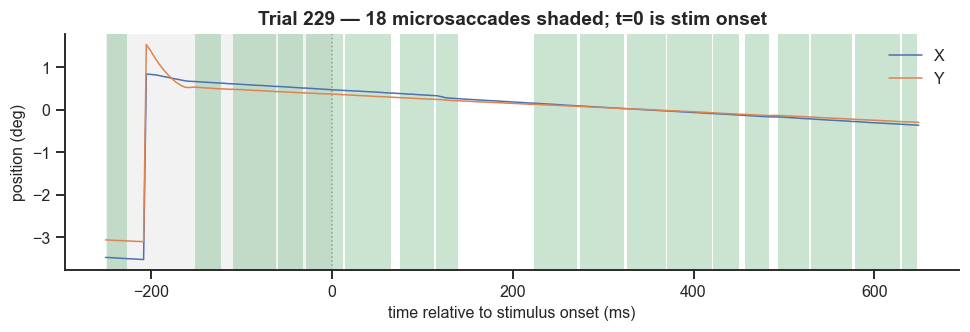

In [4]:
ex_idx = int(np.argmax(n_per_trial))
x_ex, y_ex, _ = preprocess_trial(
    ds.eye_x[ex_idx], ds.eye_y[ex_idx],
    sampling_rate_hz=cfg.sampling_rate_hz,
    lowpass_cutoff_hz=cfg.lowpass_cutoff_hz,
)
evs_ex = events_per_trial[ex_idx]
# Time axis relative to stimulus onset (so 0 = stim).
t_ms = (np.arange(ds.n_samples) - cfg.stim_onset_sample) / cfg.sampling_rate_hz * 1000

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axvspan(t_ms[0], 0, color=GREY, alpha=0.10, lw=0, label='_baseline')
ax.axvline(0, color=GREY, ls=':', lw=1, alpha=0.7)
ax.text(2, ax.get_ylim()[1] if False else 0, '', visible=False)
ax.plot(t_ms, x_ex, color=PALETTE[0], lw=1.0, label='X')
ax.plot(t_ms, y_ex, color=PALETTE[1], lw=1.0, label='Y')
for ev in evs_ex:
    ax.axvspan(ev.start_time*1000, ev.end_time*1000,
               color=ACCENT, alpha=0.30, lw=0)
ax.set(xlabel='time relative to stimulus onset (ms)',
       ylabel='position (deg)',
       title=f'Trial {ex_idx} — {len(evs_ex)} microsaccades shaded; t=0 is stim onset')
ax.legend(loc='upper right')
sns.despine(); plt.tight_layout(); plt.show()

## 3. Event descriptive statistics

Amplitude (deg)         mean=0.070  median=0.025  p95=0.375
Duration  (ms)          mean=15.0  median=10.0  p95=47.0
Peak vel  (deg/s)       mean=6.0  median=3.3  p95=21.7


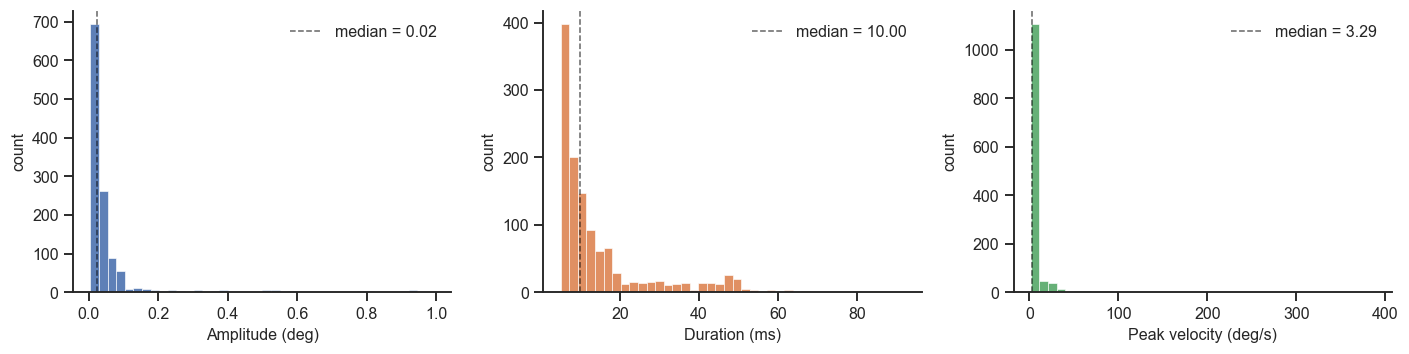

In [5]:
all_amps  = np.array([e.amplitude     for evs in events_per_trial for e in evs])
all_durs  = np.array([e.duration*1000 for evs in events_per_trial for e in evs])
all_peaks = np.array([e.peak_velocity for evs in events_per_trial for e in evs])
all_dirs  = np.array([e.direction     for evs in events_per_trial for e in evs])

def _row(name, vals, fmt='.3f'):
    print(f'{name:<22s}  mean={format(vals.mean(), fmt)}'
          f'  median={format(np.median(vals), fmt)}'
          f'  p95={format(np.percentile(vals, 95), fmt)}')
_row('Amplitude (deg)',     all_amps,  '.3f')
_row('Duration  (ms)',      all_durs,  '.1f')
_row('Peak vel  (deg/s)',   all_peaks, '.1f')

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, vals, label, color in zip(
    axes,
    [all_amps, all_durs, all_peaks],
    ['Amplitude (deg)', 'Duration (ms)', 'Peak velocity (deg/s)'],
    [PALETTE[0], PALETTE[1], PALETTE[2]],
):
    sns.histplot(vals, bins=40, color=color, ax=ax,
                 edgecolor='white', linewidth=0.4, alpha=0.9)
    ax.axvline(np.median(vals), color='black', lw=1, ls='--', alpha=0.6,
               label=f'median = {np.median(vals):.2f}')
    ax.set(xlabel=label, ylabel='count')
    ax.legend(loc='upper right')
sns.despine(); plt.tight_layout(); plt.show()

### 3.1 Direction distribution
Microsaccade direction is typically bimodally distributed along the
horizontal axis in head-fixed primate work.

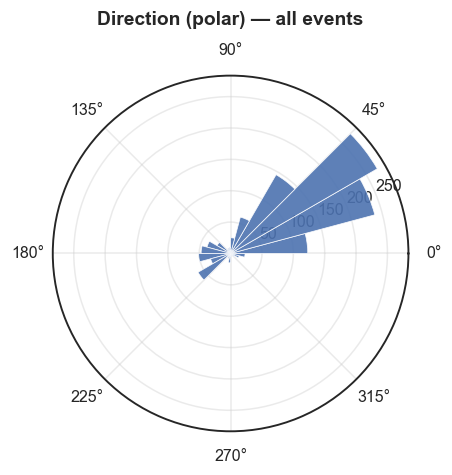

In [6]:
fig = plt.figure(figsize=(4.5, 4.5))
ax = fig.add_subplot(111, projection='polar')
n_bins = 24
edges = np.linspace(-np.pi, np.pi, n_bins + 1)
counts, _ = np.histogram(all_dirs, bins=edges)
centres = 0.5 * (edges[:-1] + edges[1:])
width = 2 * np.pi / n_bins
ax.bar(centres, counts, width=width, color=PALETTE[0],
       edgecolor='white', linewidth=0.5, alpha=0.9)
ax.set_theta_zero_location('E'); ax.set_theta_direction(1)
ax.set_title('Direction (polar) — all events', pad=12)
ax.grid(alpha=0.4); plt.tight_layout(); plt.show()

### 3.2 Main-sequence (peak velocity vs amplitude)
Real microsaccades follow a near log-linear law `log(peak) ≈ a·log(amp) + b`
with slope `a ∈ [0.7, 1.0]` (Zuber et al. 1965). A flat or noisy cloud
would mean the detector is dominated by drift / threshold-collapse
events, not real saccades.

/var/folders/vn/j52_7gtn0pq_xr8_ydc30hk80000gn/T/ipykernel_18320/1187785406.py:17: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  sns.despine(); plt.tight_layout(); plt.show()
/var/folders/vn/j52_7gtn0pq_xr8_ydc30hk80000gn/T/ipykernel_18320/1187785406.py:17: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  sns.despine(); plt.tight_layout(); plt.show()
/Users/leviackerman/Documents/projects/ms-selectivity-feature/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leviackerman/Documents/projects/ms-selectivity-feature/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


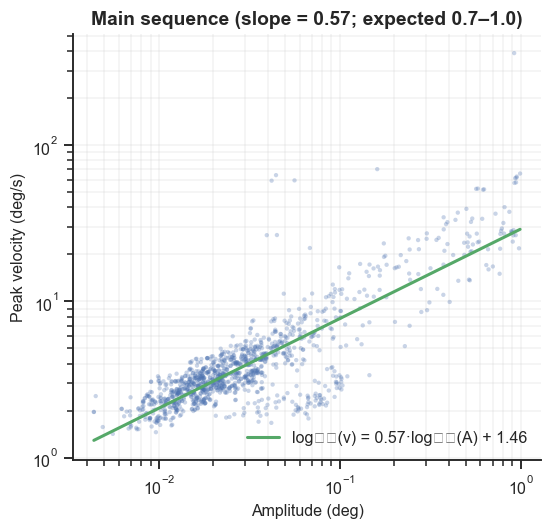

In [7]:
ok = (all_amps > 0) & (all_peaks > 0) & np.isfinite(all_amps) & np.isfinite(all_peaks)
log_a = np.log10(all_amps[ok]); log_v = np.log10(all_peaks[ok])
slope, intercept = np.polyfit(log_a, log_v, 1)
amp_grid = np.logspace(log_a.min(), log_a.max(), 100)
fit_y = 10 ** (slope * np.log10(amp_grid) + intercept)

fig, ax = plt.subplots(figsize=(5.2, 5.0))
ax.scatter(all_amps[ok], all_peaks[ok], s=8, color=PALETTE[0],
           alpha=0.30, edgecolor='none', rasterized=True)
ax.plot(amp_grid, fit_y, color=ACCENT, lw=2,
        label=f'log₁₀(v) = {slope:.2f}·log₁₀(A) + {intercept:.2f}')
ax.set(xscale='log', yscale='log',
       xlabel='Amplitude (deg)', ylabel='Peak velocity (deg/s)',
       title=f'Main sequence (slope = {slope:.2f}; expected 0.7–1.0)')
ax.grid(True, which='both', alpha=0.25)
ax.legend(loc='lower right')
sns.despine(); plt.tight_layout(); plt.show()

## 4. Microsaccade rate trace — the published falsifiable prediction

Nouri et al. 2025 report:
- baseline rate ~0.5 Hz (pre-stim)
- post-stim **suppression nadir at ~210–230 ms**
- post-stim **rebound peak at ~380–395 ms (~3.3 Hz)**

We compute the trial-averaged rate over the full trial (baseline +
post-stim) and locate the empirical nadir / peak. If those land in the
published windows, the detector is producing the right physiology.

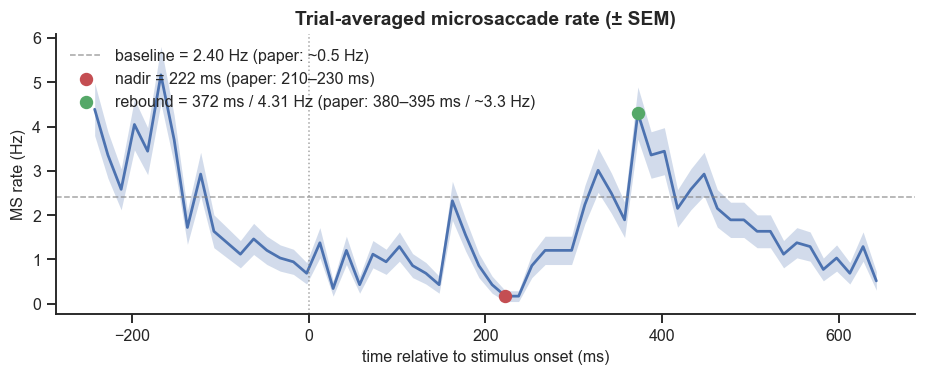

In [8]:
spec_full = RateBinSpec(
    window_start_s=-cfg.stim_onset_sample / cfg.sampling_rate_hz,
    window_end_s=(ds.n_samples - cfg.stim_onset_sample) / cfg.sampling_rate_hz,
    bin_width_s=0.015,
)
X_full = stack_trial_features(events_per_trial, spec_full)
edges = spec_full.bin_edges()
centres_ms = (edges[:-1] + edges[1:]) / 2 * 1000
mean_rate = X_full.mean(axis=0)
sem_rate  = X_full.std(axis=0, ddof=1) / np.sqrt(X_full.shape[0])

pre_mask = centres_ms < 0
post_idx = np.flatnonzero(centres_ms > 0)
baseline = mean_rate[pre_mask].mean()
nadir_i  = post_idx[np.argmin(mean_rate[post_idx])]
peak_i   = post_idx[np.argmax(mean_rate[post_idx])]

fig, ax = plt.subplots(figsize=(8.6, 3.6))
ax.fill_between(centres_ms, mean_rate - sem_rate, mean_rate + sem_rate,
                color=PALETTE[0], alpha=0.25, lw=0)
ax.plot(centres_ms, mean_rate, color=PALETTE[0], lw=1.8)
ax.axvline(0, color=GREY, ls=':', lw=1, alpha=0.7)
ax.axhline(baseline, color=GREY, ls='--', lw=1, alpha=0.7,
           label=f'baseline = {baseline:.2f} Hz (paper: ~0.5 Hz)')
ax.scatter([centres_ms[nadir_i]], [mean_rate[nadir_i]],
           color=PALETTE[3], s=60, zorder=5,
           label=f'nadir = {centres_ms[nadir_i]:.0f} ms (paper: 210–230 ms)')
ax.scatter([centres_ms[peak_i]], [mean_rate[peak_i]],
           color=ACCENT, s=60, zorder=5,
           label=f'rebound = {centres_ms[peak_i]:.0f} ms / '
                 f'{mean_rate[peak_i]:.2f} Hz (paper: 380–395 ms / ~3.3 Hz)')
ax.set(xlabel='time relative to stimulus onset (ms)',
       ylabel='MS rate (Hz)',
       title='Trial-averaged microsaccade rate (± SEM)')
ax.legend(loc='upper left'); sns.despine(); plt.tight_layout(); plt.show()

### 4.1 Same trace split by face / non-face

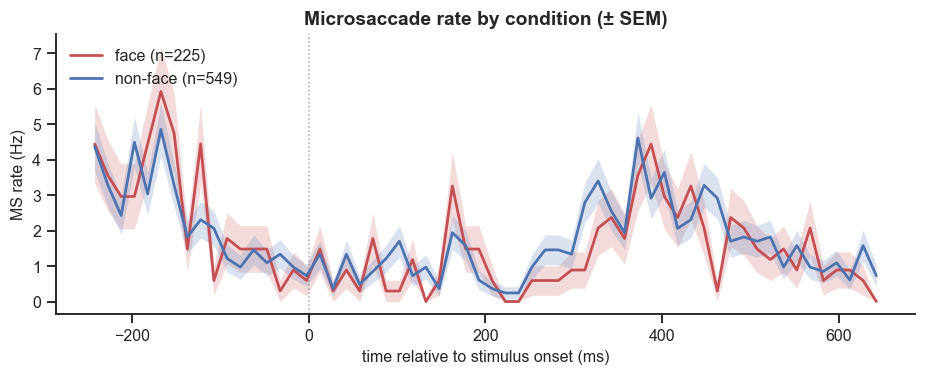

In [9]:
y = ds.is_face.astype(int)
def _mean_sem(arr):
    return arr.mean(axis=0), arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
mu_face,  sem_face  = _mean_sem(X_full[y == 1])
mu_non,   sem_non   = _mean_sem(X_full[y == 0])

fig, ax = plt.subplots(figsize=(8.6, 3.6))
ax.axvline(0, color=GREY, ls=':', lw=1, alpha=0.7)
for mu, sem, color, label in [
    (mu_face, sem_face, FACE_COLOUR,    f'face (n={int(y.sum())})'),
    (mu_non,  sem_non,  NONFACE_COLOUR, f'non-face (n={int((1-y).sum())})'),
]:
    ax.plot(centres_ms, mu, color=color, lw=1.8, label=label)
    ax.fill_between(centres_ms, mu - sem, mu + sem, color=color, alpha=0.20, lw=0)
ax.set(xlabel='time relative to stimulus onset (ms)',
       ylabel='MS rate (Hz)',
       title='Microsaccade rate by condition (± SEM)')
ax.legend(loc='upper left'); sns.despine(); plt.tight_layout(); plt.show()